# AHMED AHSRAF SAAD 7628 ASSIGNMENT 1





## Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers
from google.colab import files
import matplotlib.pyplot as plt
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# Upload the dataset
uploaded_files = files.upload()

# Setting up plot size for visualizations
plt.rcParams['figure.figsize'] = (10, 6)


Saving orbit.csv to orbit.csv


## Load Data

In [6]:
orbit_data = pd.read_csv("orbit.csv")

# Checking the first few rows to confirm data loading
orbit_data.sample(5)


,time_steps,y
1919,9.199600,84.632636
1783,7.838919,61.448658
1050,0.505253,0.255280
387,-6.128064,37.553169
548,-4.517259,20.405626


## Seperate data to numpy array

In [7]:
time_series = orbit_data['time_steps'].to_numpy()
vertical_positions = orbit_data['y'].to_numpy()


In [8]:
# Data augmentation: introduce variability with random noise and scaling factors
jitter_factor = np.random.normal(0, 0.05, size=len(orbit_data))
scaling_factor = np.random.uniform(0.9, 1.1, size=len(orbit_data))
random_noise = np.random.normal(0, 0.1, size=len(orbit_data))

# Apply augmentation to the vertical positions
augmented_y = orbit_data['y'].to_numpy() * scaling_factor + jitter_factor + random_noise

# Combine original and augmented data for training
time_series_combined = np.concatenate([orbit_data['time_steps'].to_numpy(), orbit_data['time_steps'].to_numpy()])
vertical_positions_combined = np.concatenate([orbit_data['y'].to_numpy(), augmented_y])

# Shuffle the combined data for better generalization
shuffled_indices = np.random.permutation(len(time_series_combined))
time_series_combined = time_series_combined[shuffled_indices]
vertical_positions_combined = vertical_positions_combined[shuffled_indices]


##Build the model (Try to change nb of units, nb of layers, adding dropout layers)

In [21]:
# Initialize a new model
neural_net = Sequential()

# Input layer followed by multiple hidden layers with regularization
neural_net.add(Dense(128, input_shape=(1,), activation='relu'))
neural_net.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
neural_net.add(layers.Dropout(0.15))
neural_net.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
neural_net.add(layers.Dropout(0.15))
neural_net.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

# Output layer without activation (regression)
neural_net.add(Dense(1))
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_on_plateau = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5, verbose=1)




##Compile the model

In [25]:
# Compile the neural network model for regression

neural_net.compile(optimizer='adam', loss='mse')

# Define EarlyStopping to stop training when the model stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


##Train and Evalute the model

In [26]:
# Train the neural network on the provided dataset
neural_net.fit(time_series_combined, vertical_positions_combined , epochs=300, batch_size=32,validation_split=0.2,  callbacks=[reduce_lr_on_plateau, early_stopping])

# Evaluate the model's performance
final_loss = neural_net.evaluate(time_series_combined, vertical_positions_combined)
print("Final model loss:", final_loss)


Epoch 1/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 33.2333 - val_loss: 12.1448 - learning_rate: 0.0010
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.2794 - val_loss: 17.4728 - learning_rate: 0.0010
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 34.6787 - val_loss: 7.2981 - learning_rate: 0.0010
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.8190 - val_loss: 6.6566 - learning_rate: 0.0010
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.5231 - val_loss: 15.5032 - learning_rate: 0.0010
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26.4581 - val_loss: 16.2250 - learning_rate: 0.0010
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 31.1173 - val_loss: 8.9979 - learning_rate: 0.0010
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.6233 - val_loss: 5.8719 - learning_rate: 0.0010
Epoch 9/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.3345 - val_loss: 18.0926 - learning_

##Predict with the model

In [28]:
def visualize_orbit(predicted_trajectory):
    axis_limit = int(len(predicted_trajectory) / 2)

    # Plot the reference orbit (scientist's prediction)
    plt.plot(np.arange(-axis_limit, axis_limit + 1), np.arange(-axis_limit, axis_limit + 1) ** 2,
             color="mediumseagreen")

    # Plot the predicted orbit based on model output
    plt.plot(np.arange(-axis_limit, axis_limit + 1), predicted_trajectory, color="darkorange")

    plt.axis([-40, 41, -5, 550])
    plt.legend(["Scientist's Predicted Orbit", "Model's Predicted Orbit"], loc="lower left")
    plt.title("Comparison of Model's Orbit and Scientist's Orbit")
    plt.show()


# Compare With the Scientist's Orbit

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


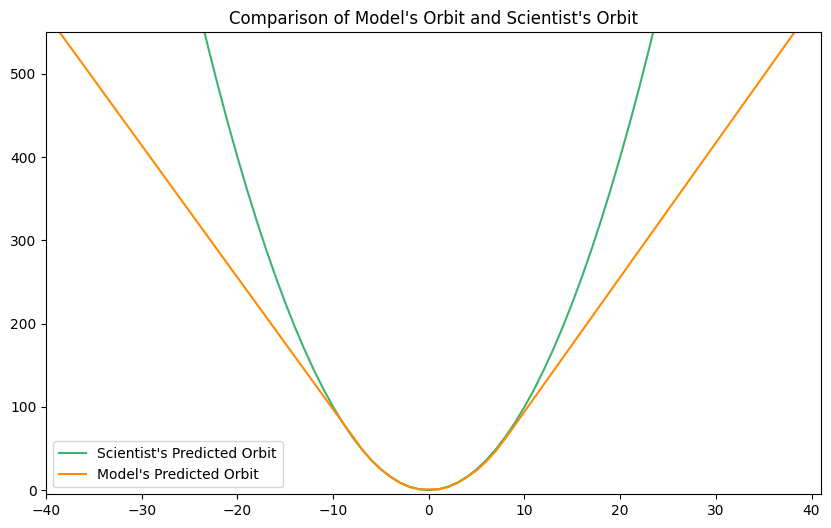

In [29]:
# Predict the trajectory for the 80-minute orbit using the trained model
predicted_orbit = neural_net.predict(np.arange(-40, 41).reshape(-1, 1))  # Reshape for single feature input

# Visualize the predicted orbit
visualize_orbit(predicted_orbit)
